# Populate the USGS Measurement Group
There is a CWMS owned USGS measurement group that needs to be populated to opt into the get_USGS_measurements.py script data collection.
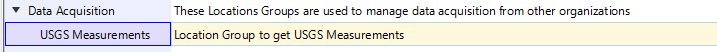
You can populate this with the CWMS-VUE GUI, your own script, or use this script to copy the members in Agency Aliases->USGS Station Number into this group.


An attribute set to 1 will allow the get_USGS_measurements.py to overwrite existing measurement data at that location. Otherwise the script will not overwrite any data that may conflict with a USGS measurement (e.g. same measurement number or similar collection datetime).


In [1]:
import cwms
import json


# load .env python environment for storing API_KEY
from dotenv import load_dotenv
import os

In [2]:
# this function will copy all 
def populate_USGS_measurements_group(office_id = str, overwrite_all_attribute = False):
    # Copy  group Agency Aliases -> USGS Station Number to Data Acquisition -> USGS Measurements

    # get USGS location aliases
    loc_group = cwms.get_location_group(loc_group_id="USGS Station Number",
                                    category_id="Agency Aliases",
                                    office_id="CWMS")

    loc_dict = loc_group.json

    # copy group to Data Acquisition -> USGS Measurements
    # write blank alias
    for location in loc_dict['assigned-locations']:
        location['alias-id'] = ''  
        if overwrite_all_attribute:
            location['attribute'] = 1

    # update group and category name
    loc_dict['office-id'] = "CWMS"
    loc_dict['id'] = 'USGS Measurements'
    description = 'Location Group to get USGS Measurements. A "1" attribute will allow measurement to be overwritten'
    loc_dict['location-category'] = {'office-id': "CWMS", 'id': 'Data Acquisition', 'description': description
        }
    loc_dict['description'] = description

    print(json.dumps(loc_dict))
    cwms.update_location_group(data = loc_dict, group_id='USGS Measurements', office_id=office_id, replace_assigned_locs=True)
 


In [3]:
# grab API variables from .env file
load_dotenv()
APIROOT = os.getenv("API_ROOT")
OFFICE = os.getenv("OFFICE")
APIKEY = os.getenv('API_KEY')

# api key needs to have the test "apikey" as a prefix to work with CDA 
apiKey = "apikey " + APIKEY
api = cwms.api.init_session(api_root = APIROOT, api_key = apiKey)

In [9]:
# toggle this variable to setup all locations to be overwritten or not
OVERWRITE = True
populate_USGS_measurements_group(office_id=OFFICE, overwrite_all_attribute = OVERWRITE)

{"office-id": "CWMS", "id": "USGS Measurements", "location-category": {"office-id": "CWMS", "id": "Data Acquisition", "description": "Location Group to get USGS Measurements. A \"1\" attribute will allow measurement to be overwritten"}, "description": "Location Group to get USGS Measurements. A \"1\" attribute will allow measurement to be overwritten", "assigned-locations": [{"location-id": "Taconite", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "GrandRapids", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "Baraboo", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "Stratford", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "RibFalls", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "BlackRivFalls", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "Neilsville", "office-id": "MVP", "alias-id": "", "attribute": 1}, {"location-id": "Northfield", "office-id": "M

In [10]:
cwms.get_location_group(loc_group_id="USGS Measurements", category_id= "Data Acquisition", office_id=OFFICE, group_office_id="CWMS").df

,location-id,office-id,attribute
0,SCOM5,MVP,1
1,Taconite,MVP,1
2,GrandRapids,MVP,1
3,Baraboo,MVP,1
4,Stratford,MVP,1
...,...,...,...
264,GraniteFallsMin,MVP,1
265,MenomonieRCedar,MVP,1
266,MerrillPrairie,MVP,1
267,Prescott_StCroix,MVP,1
